## Loan Approval system:-

## Problem Statement :- 
- Financial company "SecureTrustBank" offers personal and home loans to customers across urban and rural regions of India.
- Everyday hundreds of customers apply for loans throught online and branch applications.
- SecureTrustBank was processing this application manually and this is time-consuming, biased and inconsistent.
- As a result bank faces 2 majoy challenges:-
    1. good customers sometimes get rejected, leading to loss of busniess.
    2. High-risk customers sometimes get approved, leading to financial loss.

## Solution:-
- An intelligent loan approval system prowered by Machine Learning models that can analyse the details and predict whether loan should approved or rejected before final human verfication.

## Goal :-
- Design a Machine Learning model that learns hidden patterns from the past loan application data. And provide accurate, fast and unbaised loan approval decisions.
- To set priorities for the given challenges
  1. First priority is to minimize the high risk customers and save the financial loss
  2. Second priority is to minimize the rejection of good customer and save loss of busniess.

In [96]:
# import libraries
import pandas as pd #to deal with dataframes
from sklearn.impute import SimpleImputer #to handle missing values
import seaborn as sns #for EDA
import matplotlib.pyplot as plt #for EDA
from sklearn.preprocessing import LabelEncoder, OneHotEncoder #for encoding
from sklearn.model_selection import train_test_split # train_test_split
from sklearn.preprocessing import StandardScaler #standard feature scaling
from sklearn.linear_model import LogisticRegression #logistic Regression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score #evaluation matrics
from sklearn.model_selection import GridSearchCV # for KNN to find the nest n_neighbor value
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.naive_bayes import GaussianNB #Naive Bayers
import numpy as np

### Load Dataset

In [2]:
#load the dataset
data = pd.read_csv("loan_approval_data.csv")

#view data
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


### Learn Dataset:-

- understanding features meaning :-

1. Applicant_ID :- ID of the applicant
2. Applicant_Income :- income of the applicant per month
3. Coapplicant_Income :- income of the co-applicant per month
4. Employment_Status :- 3 options (Salaried/Self-Employed/Business)
5. Age :- age of applicant
6. Marital_Status :- 2 options(Married/Single)
7. Dependents :- number of dependents on applicant income
8. Credit_Score :- Credit-bureau-score
9. Existing_Loans :- Number of already running loans
10. DTI_Ratio :- Debt-to-Income ratio (this debt is the make sure you have enough money to pay for your debt and how much is left with you, The bank uses DTI to calculate if that leftover amount is big enough to safely fit a new loan payment)
11. Savings :- Your Saving balance
12. Collateral_Value :- Collateral value is the estimated cash worth of an asset that you pledge to a bank to secure a loan.
13. Loan_Amount :- loan amount requested
14. Loan_Term :- loan duration (months)
15. Loan_Purpose :- 4 categories (Home/Education/Personal/Business)
16. Property_Area :- 3 options (Urban/Semi-Urban/Rural)
17. Education_level :- 3 options (Graduate/Postgraduate/Undergraduate)
18. Gender :- Male/Female
19. Employer_Category :- 3 options (Govt/Private/Self)
20. Loan_Approved(Target) :- yes=Approved,no=Rejected

### Data Analysis :- 

In [3]:
#look at the null values and data types of the features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
data.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [5]:
data.describe() #only do statastic 

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


#### Analysis conclusion :- 
- useless columns are - Applicant_ID
- we have 1000 data points / rows and 20 features / columns
- we have null vlaues :- each features has 50 null values
- we have categorial features :- Employment_Status, Marital_Status, Loan_Purpose, Property_Area, Education_Level, Gender, Employer_category, Loan_Approved

#### Understanding what model to used based on the problem:- 
- Target feature is Loan_Approved :- This has 2 types of categories and the output is discrete output. Hence this problem is Binary Classification problem.
- I am going to try Logistic Regression, KNN, Naive Bayes model.

### Data Cleaning:- 

#### Drop useless columns :-

In [6]:
#drop Applicant_ID
data.drop(columns=["Applicant_ID"], axis=1, inplace=True)

#### Handle Missing Value :- 
- Two types
  1. Categorical missing values
     - use model (most occuring category)
  2. Numerical missing values
     - use mean/median to fill the values (note : mean is prefered and median is used with reasons)
- Using sklearn simpleImputer function to fill missing values : Replace missing values using a descriptive statistic (e.g. mean, median, or most frequent) along each column, or using a constant value. 

In [7]:
#seperate categorical columns and numerical columns:

#categorical col names :
#select colums with particular data type
categorical_col = data.select_dtypes(include="object").columns
categorical_col

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [8]:
#numerical col names :
numerical_col = data.select_dtypes(include="float64").columns
numerical_col

Index(['Applicant_Income', 'Coapplicant_Income', 'Age', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [9]:
#fill missing values
categorical_imputer = SimpleImputer(strategy="most_frequent")
data[categorical_col] = categorical_imputer.fit_transform(data[categorical_col])
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [10]:
numerical_imputer = SimpleImputer(strategy="mean")
data[numerical_col] = numerical_imputer.fit_transform(data[numerical_col])
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [11]:
#check the missing values are filled :- 
data.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### EDA - Exploratory Data Analysis

In [12]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [13]:
#check how balance is our output categories

op_classes_count = data["Loan_Approved"].value_counts()
op_classes_count

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

[]

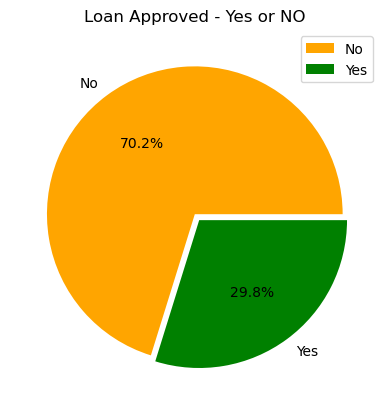

In [14]:
op_classes_count
fig, ax = plt.subplots()
ax.pie(op_classes_count, colors = ["orange","green"], labels = ["No","Yes"], autopct= "%1.1f%%", explode=[0,0.05] )
plt.title("Loan Approved - Yes or NO")
plt.legend()
plt.plot()

- we have imbalance, skewed data

[Text(0, 0, '621'), Text(0, 0, '379')]

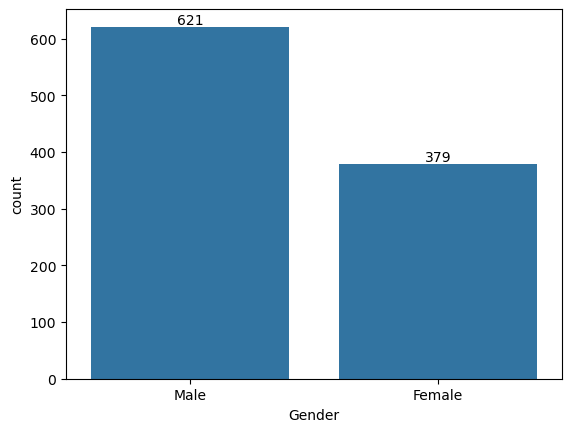

In [15]:
#Checking all the categorical feature spread 

#Gender
gender_count = data["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0],fontsize=10)

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

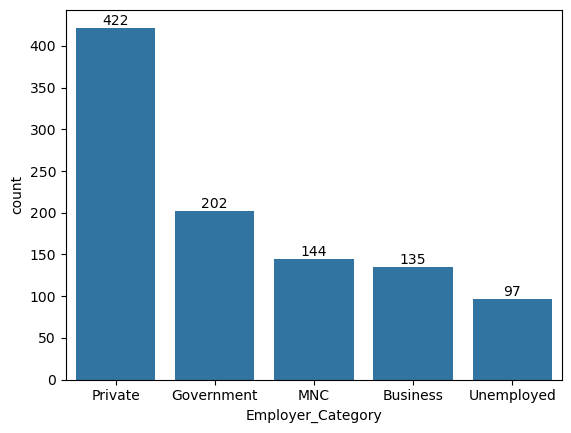

In [16]:
#Employer_Category
Employer_Category_count = data["Employer_Category"].value_counts()
ax = sns.barplot(Employer_Category_count)
ax.bar_label(ax.containers[0],fontsize=10)

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

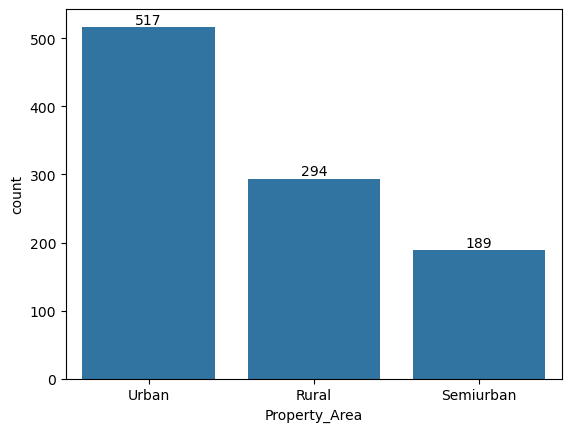

In [17]:
#Property_Area
Property_Area_count = data["Property_Area"].value_counts()
ax = sns.barplot(Property_Area_count)
ax.bar_label(ax.containers[0],fontsize=10)

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

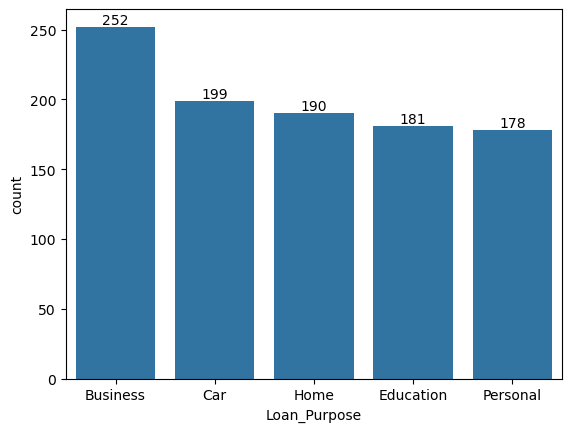

In [18]:
#Loan_Purpose
Loan_Purpose_count = data["Loan_Purpose"].value_counts()
ax = sns.barplot(Loan_Purpose_count)
ax.bar_label(ax.containers[0],fontsize=10)

[Text(0, 0, '643'), Text(0, 0, '357')]

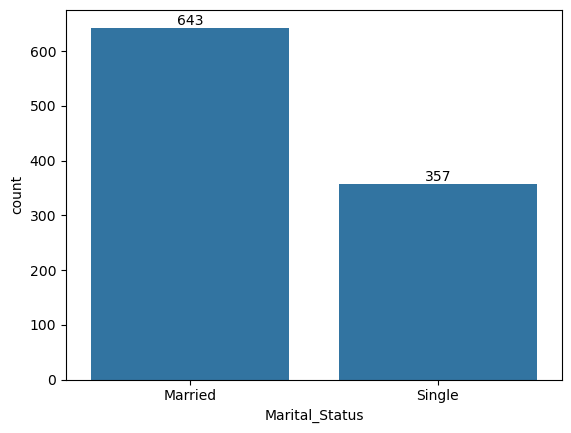

In [19]:
#Marital_Status
Marital_Status_count = data["Marital_Status"].value_counts()
ax = sns.barplot(Marital_Status_count)
ax.bar_label(ax.containers[0],fontsize=10)

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

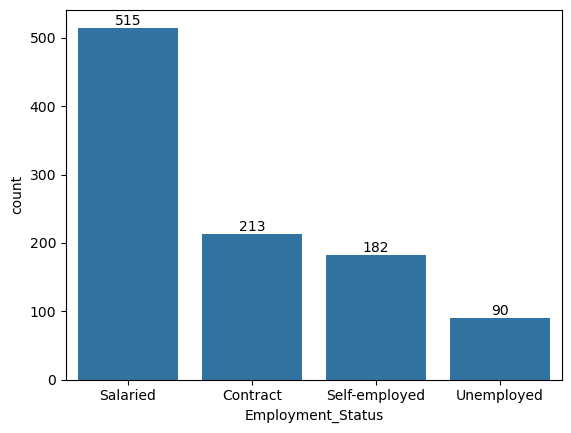

In [20]:
#Employment_Status_count
Employment_Status_count = data["Employment_Status"].value_counts()
ax = sns.barplot(Employment_Status_count)
ax.bar_label(ax.containers[0],fontsize=10)

In [21]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


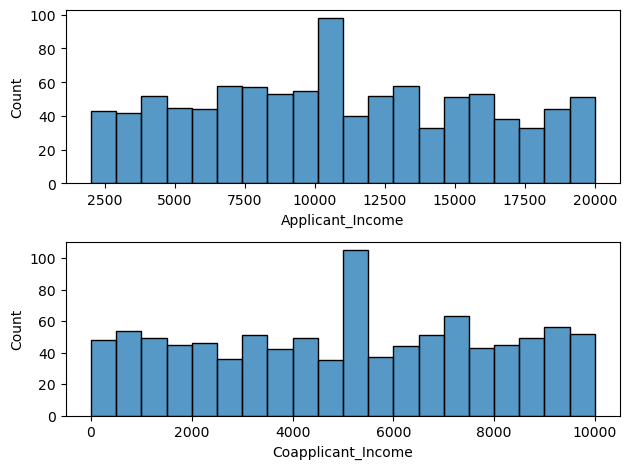

In [22]:
#analyse income and co applicant income
fig, axes = plt.subplots(2)

sns.histplot(ax=axes[0],
             data= data,
             x = "Applicant_Income",
             bins = 20
            )

sns.histplot(ax=axes[1],
             data= data,
             x = "Coapplicant_Income",
             bins = 20
            )

fig.tight_layout()

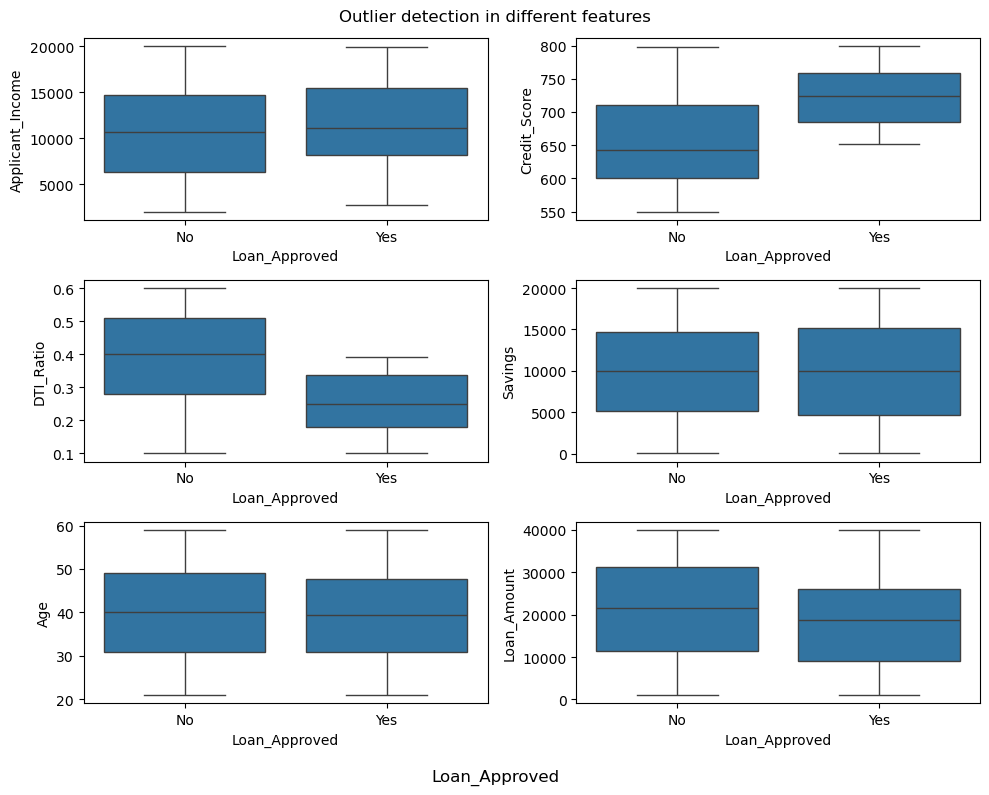

In [23]:
# check for outliers on the important features - Applicant_Income, Credit_Score, DTI_Ratio,Savings, Age, Loan_Amount

fig, axes = plt.subplots(3,2, figsize=(10, 8))

sns.boxplot(ax=axes[0,0], data=data, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=data, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=data, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=data, x="Loan_Approved", y="Savings")
sns.boxplot(ax=axes[2,0], data=data, x="Loan_Approved", y="Age")
sns.boxplot(ax=axes[2,1], data=data, x="Loan_Approved", y="Loan_Amount")

fig.suptitle("Outlier detection in different features")
fig.supxlabel("Loan_Approved")
fig.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

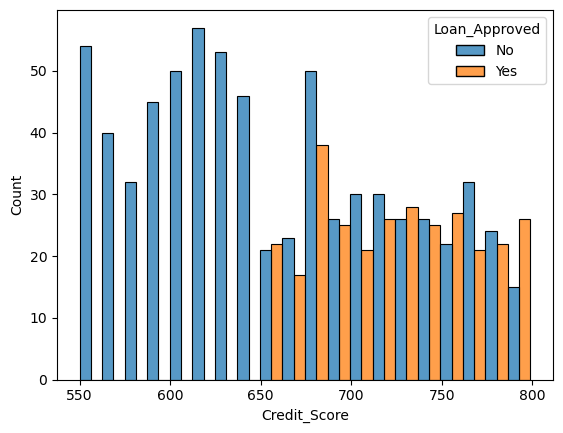

In [24]:
#Lets see if there is any credit score range where the loan got approved
sns.histplot(data= data,
             x = "Credit_Score",
             hue= "Loan_Approved",
             multiple="dodge",
             bins = 20
            )

### EDA conclusion:- 
- Credit score gives direct relation to Loan Approval
- No outliers are detected

### Feature Encoding

In [25]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

#### We can do two types of encoding 
1. Label encoding for ordinal data
   - columns :- Education_Level, Loan_Approved
3. OneHotEncoding for nomial data
   - columns :- Employment_Status, Marital_Status, Loan_Purpose, Property_Area, Gender, Employer_Category

In [27]:
#label encoding
le_cols = ["Education_Level","Loan_Approved"]

le = LabelEncoder()

data["Education_Level"] = le.fit_transform(data["Education_Level"])
data["Loan_Approved"] = le.fit_transform(data["Loan_Approved"])

In [28]:
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [40]:
#OneHotEncoding
ohe_cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output= False, handle_unknown='ignore')
ohe_data_array = ohe.fit_transform(data[ohe_cols])

#new cols for ohe 
ohe_cols_new = ohe.get_feature_names_out()

#convert into dataframe from array
ohe_data_df = pd.DataFrame(ohe_data_array, columns=ohe_cols_new)

#merge new data and new ohe df data and remove old cols before ohe
data = pd.concat([data.drop(columns=ohe_cols, axis=1), ohe_data_df], axis=1)
data

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

#### Correlation Matrix:-

In [45]:
#select all the numerical cols
num_col = data.select_dtypes("number")

#make correlation metrix
corr_matrix = num_col.corr()

#check correlation of all feature with target feature
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

#### Co-rreation heatmap

<Axes: >

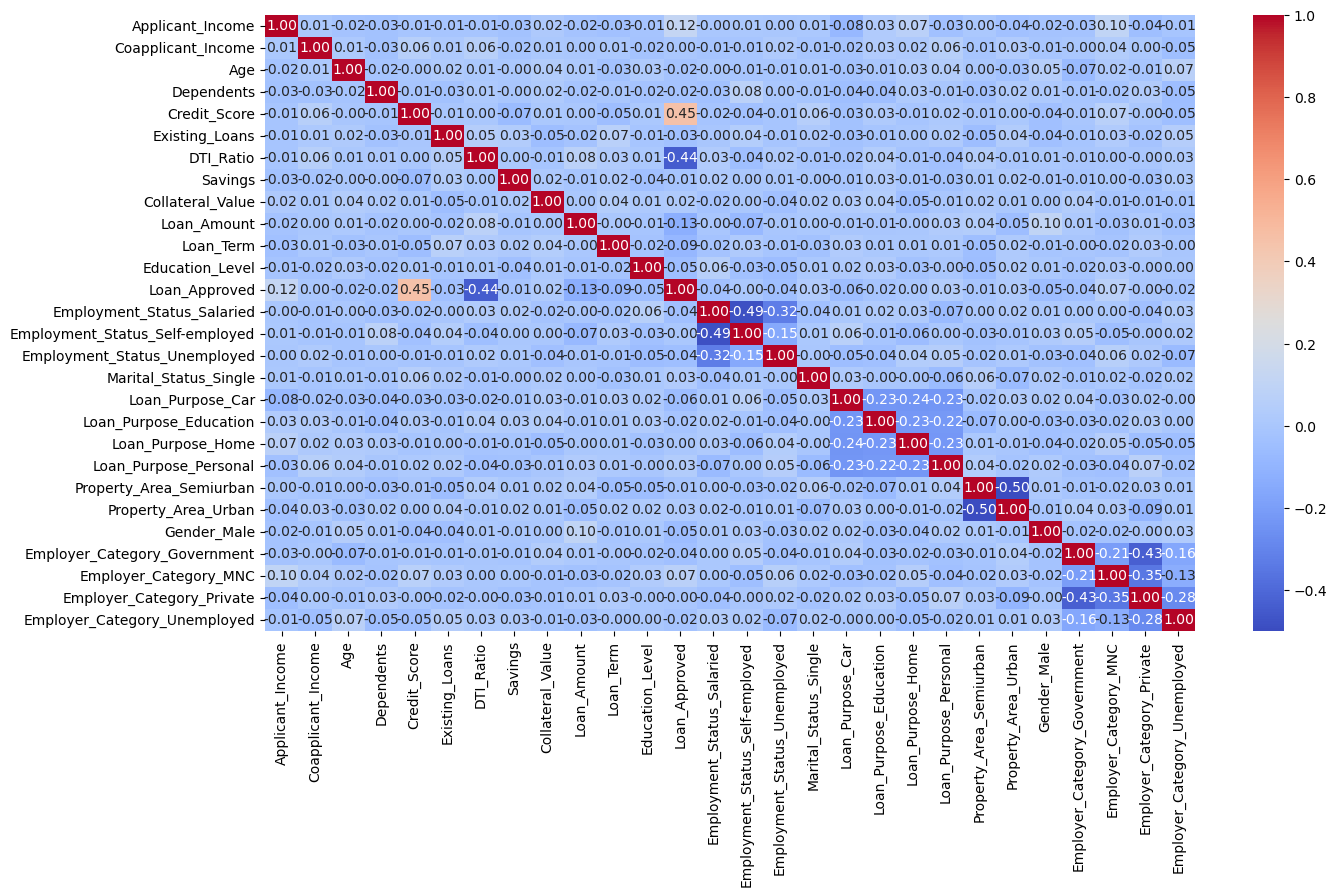

In [52]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot= True,
    cmap = "coolwarm",
    fmt='.2f'
)

### Train _ test split

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [56]:
X = data.drop("Loan_Approved",axis=1)
y = data["Loan_Approved"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

### Feature scaling

In [64]:
#use standard scaling:-
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #no need to give info about mean and SD

In [66]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

###  Training models
- we are using 3 model Logistic Regression, KNN, Naive Bayers

###Evaluation
- our primary goal is to mini the high risk customers that get approved => we want to mini False positive(FP) in the model. For this we use Precision matric
- 2nd goal is to mini the good cutmoers that sometimes gets rejected => calculate the False Negative(FN) and mini it=> we can measure this with recall
- to maintain this two we can use recall

#### Logistic Regression

In [71]:
#initialize model
model_lr = LogisticRegression(random_state=0)

#train model
model_lr.fit(X_train_scaled,y_train)

#predict y
y_pred = model_lr.predict(X_test_scaled)

#Evaluation
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

Precision =  0.7833333333333333
recall =  0.7704918032786885
accuracy =  0.865
confusion Matric = 
 [[126  13]
 [ 14  47]]


#### KNN classifier

In [86]:
#simple knn

#initialize model
model_knn = KNeighborsClassifier(n_neighbors=5)

#train model
model_knn.fit(X_train_scaled,y_train)

#predict y
y_pred = model_knn.predict(X_test_scaled)

#Evaluation
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

Precision =  0.6274509803921569
recall =  0.5245901639344263
accuracy =  0.76
confusion Matric = 
 [[120  19]
 [ 29  32]]


In [90]:
#best hyperparametre for KNN
parameters = {"n_neighbors" : [3,5,7,9,11,13]}
model_knn = KNeighborsClassifier()

#initialize model
model_knn_cv = GridSearchCV(model_knn, 
                            parameters,
                            cv = 5,
                            scoring = "precision"
                           )

#train model
model_knn_cv.fit(X_train_scaled,y_train)

#predict y
y_pred = model_knn_cv.predict(X_test_scaled)

#Evaluation
print("best n_neighour value = ",model_knn_cv.best_params_)
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

best n_neighour value =  {'n_neighbors': 13}
Precision =  0.7317073170731707
recall =  0.4918032786885246
accuracy =  0.79
confusion Matric = 
 [[128  11]
 [ 31  30]]


#### Naive Bayers

In [84]:
#initialize model
model_nb = GaussianNB()

#train model
model_nb.fit(X_train_scaled,y_train)

#predict y
y_pred = model_nb.predict(X_test_scaled)

#Evaluation
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

Precision =  0.8035714285714286
recall =  0.7377049180327869
accuracy =  0.865
confusion Matric = 
 [[128  11]
 [ 16  45]]


### Conclusion of best model:-
- on the based of precison and recall:-
Naive Bayes is the best model from the above three models that can handle FP and FN values which was the main goal of our problem.
- in naive bayes model predicts
  1. FP = 11 (false negative which is model predict loan approved for high risk customers)
  2. FN = 16 (false positive which is model predict loan not approved for good customers)

### Feature Engineering:-
1. From our correlation matrix we saw the credit score has high positive correlation and DIT_ratio has high negative correlation with our target feature.
- Therefore, we will make new features by increasing the impact of this feature by converting them into polynomial feature
- square the values of this both feature

In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [99]:
#add / transform our feature
data["Credit_Score_sq"] = data["Credit_Score"] ** 2
data["DTI_Ratio_sq"] = data["DTI_Ratio"] ** 2

#solve skewed feature - Applicant_Income                                    
#data["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = data.drop(["DTI_Ratio","Credit_Score","Loan_Approved"], axis = 1)
y = data["Loan_Approved"]

#split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

#feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #no need to give info about mean and SD

In [100]:
#training on best model Naive Bayes
#initialize model
model_nb = GaussianNB()

#train model
model_nb.fit(X_train_scaled,y_train)

#predict y
y_pred = model_nb.predict(X_test_scaled)

#Evaluation
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

Precision =  0.7833333333333333
recall =  0.7704918032786885
accuracy =  0.865
confusion Matric = 
 [[126  13]
 [ 14  47]]


In [101]:
#initialize model Logistic Regression
model_lr = LogisticRegression(random_state=0)

#train model
model_lr.fit(X_train_scaled,y_train)

#predict y
y_pred = model_lr.predict(X_test_scaled)

#Evaluation
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

Precision =  0.7903225806451613
recall =  0.8032786885245902
accuracy =  0.875
confusion Matric = 
 [[126  13]
 [ 12  49]]


In [102]:
#KNN
#best hyperparametre for KNN
parameters = {"n_neighbors" : [3,5,7,9,11,13]}
model_knn = KNeighborsClassifier()

#initialize model
model_knn_cv = GridSearchCV(model_knn, 
                            parameters,
                            cv = 5,
                            scoring = "precision"
                           )

#train model
model_knn_cv.fit(X_train_scaled,y_train)

#predict y
y_pred = model_knn_cv.predict(X_test_scaled)

#Evaluation
print("best n_neighour value = ",model_knn_cv.best_params_)
print("Precision = ", precision_score(y_test,y_pred))
print("recall = ", recall_score(y_test,y_pred))
print("accuracy = ", accuracy_score(y_test,y_pred))
print("confusion Matric = \n", confusion_matrix(y_test,y_pred))

best n_neighour value =  {'n_neighbors': 13}
Precision =  0.7368421052631579
recall =  0.45901639344262296
accuracy =  0.785
confusion Matric = 
 [[129  10]
 [ 33  28]]


### Conclusion
- still the Naive bayes is most trust worth in terms of 